# Stage 1: Case Study Dataset for Task 1 - 5
A common challenge for a car dealership when purchasing a used car at an auto auction is assessing the risk that the vehicle may have serious issues that prevent it from being sold to customers. The auto community calls these unfortunate purchases "kicks".

Kicked cars often result from tampered odometers, mechanical issues the dealer is unable to address, issues with obtaining the vehicle title from the seller, or other unforeseen problems. Kick cars can be very costly for dealers, including transportation costs, throwaway repair work, and market losses from reselling the vehicle.

A dealership manager would like to determine which cars are at higher risk of being kicked. This will provide real value to the dealership by offering the best possible inventory selection to its customers. They have been collecting data for many years and have also manually labelled it.

## Task 1: Data preparation for modelling (3.5 marks)
1. The dataset may include irrelevant and redundant variables to the underlying ML task. What variables did you include in the modelling, and what were their roles and measurement level set? Justify your choice.
2. Did you have to fix any data quality problems, including data imputation? Detail them.
**2. Fixes for data quality problems and data imputation:**
Yes, several significant data quality issues were addressed to ensure compatibility with Scikit-Learn models, which do not natively accept missing values (`NaN`).

* **String/Categorical Variables:** Missing or ambiguous values (e.g., "?", "NOT AVAIL", `NaN`) in columns like `Size`, `Make`, and `Auction` were standardized and imputed with the string "N/A". This approach treats missingness as its own distinct category rather than discarding the rows.
* **Boolean Variables:** Columns such as `PRIMEUNIT` and `IsOnlineSale` contained missing values. Since a missing boolean flag in auction data typically implies the absence of that specific trait (e.g., not a premium unit, not sold online), these were logically imputed with `False`. 
* **Numerical Variables:** Missing values in pricing columns (e.g., `MMRAcquisition...`) and `VehOdo` were imputed using their respective column means. For `VehYear`, missing values were imputed using the median to prevent fractional years, and all numeric types were properly cast to integers to prevent model conflicts.
3. Report the proportion of values of the target variable for the dataset before and after the pre-processing.

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

FILE = "kick_1.csv"
# Read dataset
df = pd.read_csv(FILE)

def explore(df):
    skip_cols = ["PurchaseID", "PurchaseDate", "PurchaseTimestamp", "WarrantyCost"]
    for col in df.columns:
        if col in skip_cols:
            continue
        print(col, df[col].dtype, df[col].unique())

def normalize_str_column(df, col_name):
    # Standardize string missing indicators and convert to uppercase category 'N/A':
    df[col_name] = df[col_name].replace(["NOT AVAIL", "?", np.nan], "N/A").astype(str).str.upper()

def normalize_numeric_column(df, col_name):
    # Impute missing values with column mean:
    df[col_name] = df[col_name].fillna(df[col_name].mean())

# Function definition with default parameter fill_value=False:
def normalize_bool_column(df, col_name, fill_value=False):
    # Standardize boolean representations and impute missing values with default boolean flag
    df[col_name] = (
        df[col_name]
        .astype(str)
        .str.strip()
        .str.upper()
        .replace(["?", "NAN", "NONE", "", np.nan], pd.NA)
        .map({
            "YES": True, "Y": True,
            "NO": False, "N": False,
            "0": False, "0.0": False,
            "1": True, "1.0": True
        })
    )
    # Fill remaining missing values with fill_value and cast to standard boolean
    df[col_name] = df[col_name].fillna(fill_value).astype(bool)

def convert_string_to_int_na_fill_mean(df, col_name):
    # Coerce to numeric, impute missing values with mean, and round to integer
    df[col_name] = pd.to_numeric(df[col_name], errors="coerce")
    df[col_name] = df[col_name].fillna(df[col_name].mean()).round().astype(int) 

def convert_string_to_float_na_fill_mean(df, col_name):
    # Coerce to numeric and impute missing values with mean
    df[col_name] = pd.to_numeric(df[col_name], errors="coerce")
    df[col_name] = df[col_name].fillna(df[col_name].mean())

# Drop irrelevant identifiers and duplicate redundant features:
df.drop(['PurchaseID', 'PurchaseDate', 'PurchaseTimestamp', 'WheelTypeID', 'TopThreeAmericanName'], axis=1, inplace=True)

# Impute VehYear with median and cast to integer:
df["VehYear"] = pd.to_numeric(df["VehYear"], errors="coerce")
df["VehYear"] = df["VehYear"].fillna(df["VehYear"].median()).astype(int)

# Impute VehOdo with mean and cast to integer:
df["VehOdo"] = pd.to_numeric(df["VehOdo"], errors="coerce")
df["VehOdo"] = df["VehOdo"].fillna(df["VehOdo"].mean()).astype(int)

# Normalize categorical string features:
normalize_str_column(df, 'Auction')
normalize_str_column(df, 'Make')
normalize_str_column(df, 'Color')
normalize_str_column(df, 'Transmission')
normalize_str_column(df, 'WheelType')
normalize_str_column(df, 'Nationality')
normalize_str_column(df, 'Size')
normalize_str_column(df, 'AUCGUART')
normalize_str_column(df, 'VNST')

# Normalize numeric continuous feature:
normalize_numeric_column(df, 'WarrantyCost')

# Normalize binary indicator variables
normalize_bool_column(df, 'PRIMEUNIT', fill_value=False)
normalize_bool_column(df, 'ForSale', fill_value=True)
normalize_bool_column(df, 'IsOnlineSale', fill_value=False)
normalize_bool_column(df, 'IsBadBuy', fill_value=False)

# Clean and impute all MMR acquisition and current pricing variables
convert_string_to_int_na_fill_mean(df, 'MMRAcquisitionAuctionAveragePrice')
convert_string_to_int_na_fill_mean(df, 'MMRAcquisitionAuctionCleanPrice')
convert_string_to_int_na_fill_mean(df, 'MMRAcquisitionRetailAveragePrice')
convert_string_to_int_na_fill_mean(df, 'MMRAcquisitonRetailCleanPrice')
convert_string_to_int_na_fill_mean(df, 'MMRCurrentAuctionAveragePrice')
convert_string_to_int_na_fill_mean(df, 'MMRCurrentAuctionCleanPrice')
convert_string_to_int_na_fill_mean(df, 'MMRCurrentRetailAveragePrice')
convert_string_to_int_na_fill_mean(df, 'MMRCurrentRetailCleanPrice')
convert_string_to_float_na_fill_mean(df, 'MMRCurrentRetailRatio')

# Ensure VehBCost is properly converted to numeric and imputed
df['VehBCost'] = pd.to_numeric(df['VehBCost'], errors='coerce')
df['VehBCost'] = df['VehBCost'].fillna(df['VehBCost'].mean())

# Verification: Confirm that zero NaNs remain in the preprocessed DataFrame
print("\n=== AFTER PROCESSING: Check for Remaining NaNs ===")
print(df.isna().sum()[df.isna().sum() > 0])

# Explore again:
#print('\n=== AFTER PROCESSING==')
#explore(df)

Y = df["IsBadBuy"]
df.head()




=== AFTER PROCESSING: Check for Remaining NaNs ===
Series([], dtype: int64)


,Auction,VehYear,Make,Color,Transmission,WheelType,VehOdo,Nationality,Size,MMRAcquisitionAuctionAveragePrice,...,MMRCurrentRetailCleanPrice,MMRCurrentRetailRatio,PRIMEUNIT,AUCGUART,VNST,VehBCost,IsOnlineSale,WarrantyCost,ForSale,IsBadBuy
0,OTHER,2008,DODGE,RED,AUTO,COVERS,51099,AMERICAN,MEDIUM,8566,...,12505,0.941783,False,N/A,NC,7800.0,False,920.0,True,False
1,OTHER,2008,DODGE,RED,AUTO,COVERS,48542,AMERICAN,MEDIUM,8566,...,10571,0.922618,False,N/A,NC,7800.0,False,834.0,True,False
2,OTHER,2008,CHRYSLER,SILVER,AUTO,COVERS,46318,AMERICAN,MEDIUM,8835,...,9932,0.935159,False,N/A,NC,7800.0,False,834.0,True,False
3,OTHER,2008,CHEVROLET,RED,AUTO,COVERS,50413,AMERICAN,COMPACT,7165,...,8739,0.931457,False,N/A,NC,6000.0,False,671.0,True,False
4,OTHER,2008,DODGE,SILVER,AUTO,COVERS,50199,AMERICAN,MEDIUM,8566,...,9908,0.906944,False,N/A,NC,7800.0,False,920.0,True,False


#Task 2: Decision Tree Modelling (4.5 marks)
1. Build a decision tree using the default setting. Examine the tree results and answer the following:
- What parameters have been used to build the tree? Detail them.
- What data split was used to create training and test datasets?
- What is the classification accuracy on the training and test datasets?
- What is the size of the tree (number of nodes and rules)?
- Which variable is used for the first split? What are the variables that are used for the second split?
- What are the five important variables in building the tree?
- Report if you see any evidence of model overfitting.
2. Build another decision tree tuned with GridSearchCV. Examine the tree results.
- What are the optimal parameters for this decision tree? Explain your choice of hyperparameters to search, and the chosen search range(s)?
- What is the classification accuracy on the training and test datasets?
- What is the size of the chosen tree (number of nodes and rules)?
- Which variable is used for the first split? What are the variables that are used for the second split?
- What are the five important variables in building the tree?
- Report if you see any evidence of model overfitting.
3. What is the significant difference between these two decision tree models – default (Task 2.1) and using GridSearchCV (Task 2.2)? How do they compare performance-wise? Produce the ROC curve for both DTs. Explain why those changes may have happened.
4. From the better model, can you provide the characteristics of cars most likely to be ‘kicks’? If it is hard to comprehend, discuss why.

# Further Data Prep for Scikit-Learn

In [2]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, RocCurveDisplay
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

# 1. Prepare data for Scikit-Learn (Encoding categorical variables)
# Decision Trees in sklearn require numerical inputs. We use one-hot encoding for strings.
categorical_cols = df.select_dtypes(include=['object']).columns
X = pd.get_dummies(df.drop('IsBadBuy', axis=1), columns=categorical_cols, drop_first=True)

# Target variable
y = df['IsBadBuy'].astype(int)

# Task 2.1: Data split
# Using an 80/20 split as it is standard practice, with a fixed random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (33180, 119)
Testing set shape: (8296, 119)


## Task 2.1: Default Decision Tree

**1. Parameters used to build the tree:**
We initialized the `DecisionTreeClassifier` using the default parameters provided by scikit-learn (e.g., `criterion='gini'`, `max_depth=None`, `min_samples_split=2`). The `random_state` was set to 42 for reproducibility.

**2. Data split:**
The dataset was split into training and test sets using an 80/20 ratio (`test_size=0.2`). We used `stratify=y` to maintain the same proportion of 'Kick' (bad buy) cars in both datasets, which is crucial for handling target variable distribution.

**3. Classification accuracy:**
* Training Accuracy: 0.9998
* Testing Accuracy: 0.8396

**4. Size of the tree:**
* Number of nodes: 7621
* Number of leaves (rules): 3811

**5. Variables used for splits:**
* **First split:** WheelType_N/A
* **Second split:** VehYear (Left), Auction_MANHEIM (Right)

**6. Top 5 important variables:**
1. WheelType_N/A                        0.173175
2. VehOdo                               0.046256
3. MMRAcquisitionAuctionAveragePrice    0.029370
4. MMRCurrentRetailRatio                0.029301
5. MMRCurrentRetailCleanPrice           0.026030

**7. Evidence of model overfitting:**
Yes, there is definitive and severe evidence of model overfitting in the default Decision Tree model:

* **Substantial Accuracy Gap:** The tree achieved an almost perfect **Training Accuracy of 99.98%**, whereas the **Testing Accuracy dropped significantly to 83.96%** (a performance discrepancy of ~16.02%).
* **Lack of Regularization & Node Memorization:** Because default scikit-learn parameters place no restrictions on tree growth (`max_depth=None`, `min_samples_split=2`, `min_samples_leaf=1`), the algorithm recursively partitioned the training feature space until virtually every leaf node was 100% pure. 
* **Impact on Generalization:** Instead of capturing underlying, generalizable relationships between vehicle attributes and bad buys, the unpruned tree memorized sample-specific noise, individual outliers, and idiosyncratic training patterns. Consequently, its predictive performance degraded substantially when evaluated on unseen testing data.

In [3]:
# Train default Decision Tree
dt_default = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_default.fit(X_train, y_train)

# Predictions and Accuracy
y_train_pred = dt_default.predict(X_train)
y_test_pred = dt_default.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("=== Task 2.1: Default Decision Tree ===")
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Number of nodes: {dt_default.tree_.node_count}")
print(f"Number of leaves: {dt_default.tree_.n_leaves}")

# Extract split features
tree = dt_default.tree_
feature_names = X.columns
first_split_feature = feature_names[tree.feature[0]]
left_child_feature = feature_names[tree.feature[tree.children_left[0]]]
right_child_feature = feature_names[tree.feature[tree.children_right[0]]]

print(f"\nFirst split variable: {first_split_feature}")
print(f"Second split variables: {left_child_feature} (Left), {right_child_feature} (Right)")

# Top 5 Important Variables
importances = pd.Series(dt_default.feature_importances_, index=feature_names)
top5_default = importances.sort_values(ascending=False).head(5)
print("\nTop 5 Important Variables:")
print(top5_default)

=== Task 2.1: Default Decision Tree ===
Training Accuracy: 0.9998
Test Accuracy: 0.8169
Number of nodes: 7207
Number of leaves: 3604

First split variable: WheelType_N/A
Second split variables: VehYear (Left), Auction_MANHEIM (Right)

Top 5 Important Variables:
WheelType_N/A                   0.173175
VehOdo                          0.078282
VehBCost                        0.067833
MMRCurrentRetailRatio           0.064138
MMRCurrentRetailAveragePrice    0.043448
dtype: float64


## Task 2.2: Decision Tree Modelling with GridSearchCV

**1. Optimal parameters and choice of hyperparameters:**
* Optimal parameters found: `{'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 100}`
* **Explanation:** To combat the severe overfitting observed in the default tree, we defined a search grid to regularize (prune) the model. 
    * `max_depth` (e.g., 5, 10, 15): Setting the optimal depth to 5 strictly constrains vertical tree growth, preventing the model from partitioning data down to single noisy samples.
    * `min_samples_split` (searched: 10, 50, 100) & `min_samples_leaf` (searched: 10, 20, 50): Requiring at least 100 samples to attempt a split and a minimum of 10 samples per leaf node ensures every decision boundary is supported by a statistically meaningful subgroup of vehicles.
    * `criterion` (searched: 'gini', 'entropy'): 'entropy' (information gain) was selected over Gini impurity, indicating that minimizing entropy provides cleaner class separation for this particular auction dataset.

**2. Classification accuracy:**
* Training Accuracy:  0.8990
* Testing Accuracy: 0.8957

**3. Size of the tree:**
* Number of nodes: 41
* Number of leaves (rules): 21

**4. Variables used for splits:**
* **First split:**  WheelType_N/A
* **Second split:** VehYear (Left), Auction_MANHEIM (Right)

**5. Top 5 important variables:**
1. WheelType_N/A                        0.688373
2. VehYear                              0.112979
3. Auction_MANHEIM                      0.042450
4. MMRAcquisitionAuctionAveragePrice    0.029808
5. MMRAcquisitionAuctionCleanPrice      0.029059

**6. Evidence of model overfitting:**
There is clear, empirical evidence that hyperparameter tuning via GridSearchCV has successfully eliminated the severe overfitting exhibited by the default decision tree:

* **Default Model (Task 2.1) Overfitting:**
  * In the unconstrained default decision tree, the **Training Accuracy was 99.98%**, whereas the **Testing Accuracy dropped to 83.96%**. 
  * This substantial ~16.02% performance gap indicates that the default tree expanded without depth or leaf constraints, effectively memorizing the noise, outliers, and idiosyncratic patterns of the training partition rather than learning true generalizable rules.

* **Tuned Model (Task 2.2) Generalization:**
  * After hyperparameter tuning with GridSearchCV, the optimal model yielded a **Training Accuracy of 89.90%** and a **Testing Accuracy of 89.57%**.
  * The performance gap narrowed to a negligible **0.33%**, and the test accuracy improved from 83.96% to 89.57%. This demonstrates that the regularized constraints (`max_depth=5`, `min_samples_split=100`, and `min_samples_leaf=10`) effectively pruned redundant subtrees and prevented node over-specialization, resulting in a robust, high-generalization model for unseen auction data.


** Note. below script takes around 10 minute on my laptop, it does not utilise GPU. **
- To reduce excusion time, changed the cv value from 5 to 3, added an option verbose=1 to check realtime progress

In [4]:
# Define hyperparameter grid for tuning
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [10, 50, 100],
    'min_samples_leaf': [10, 20, 50]
}

# Run GridSearchCV (using cv=3 for robust cross-validation)
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=RANDOM_STATE), param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

best_dt = grid_search.best_estimator_

# Predictions and Accuracy
y_train_pred_cv = best_dt.predict(X_train)
y_test_pred_cv = best_dt.predict(X_test)

train_acc_cv = accuracy_score(y_train, y_train_pred_cv)
test_acc_cv = accuracy_score(y_test, y_test_pred_cv)

print("=== Task 2.2: GridSearchCV Decision Tree ===")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Training Accuracy: {train_acc_cv:.4f}")
print(f"Test Accuracy: {test_acc_cv:.4f}")
print(f"Number of nodes: {best_dt.tree_.node_count}")
print(f"Number of leaves: {best_dt.tree_.n_leaves}")

# Extract split features
tree_cv = best_dt.tree_
first_split_feature_cv = feature_names[tree_cv.feature[0]]
left_child_feature_cv = feature_names[tree_cv.feature[tree_cv.children_left[0]]]
right_child_feature_cv = feature_names[tree_cv.feature[tree_cv.children_right[0]]]

print(f"\nFirst split variable: {first_split_feature_cv}")
print(f"Second split variables: {left_child_feature_cv} (Left), {right_child_feature_cv} (Right)")

# Top 5 Important Variables
importances_cv = pd.Series(best_dt.feature_importances_, index=feature_names)
top5_cv = importances_cv.sort_values(ascending=False).head(5)
print("\nTop 5 Important Variables:")
print(top5_cv)

Fitting 3 folds for each of 72 candidates, totalling 216 fits
=== Task 2.2: GridSearchCV Decision Tree ===
Best Parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 50}
Training Accuracy: 0.8990
Test Accuracy: 0.8957
Number of nodes: 47
Number of leaves: 24

First split variable: WheelType_N/A
Second split variables: VehYear (Left), Auction_MANHEIM (Right)

Top 5 Important Variables:
WheelType_N/A       0.678258
VehYear             0.133666
VehBCost            0.055647
Auction_MANHEIM     0.041827
Transmission_N/A    0.021815
dtype: float64


## Task 2.3 & 2.4: Comparison and Insights

**Comparison between Default and GridSearchCV models:**
The primary difference lies in model complexity and generalization. The default decision tree recursively expanded nodes until all leaves were pure, resulting in an overly complex, deep structure that perfectly memorized the training data (overfitting) but failed to generalize well to unseen data. By applying `GridSearchCV`, we constrained the tree's growth through structural parameters (`max_depth`, `min_samples_leaf`). Consequently, the tuned model has far fewer nodes and rules, demonstrating much better generalizability with stable accuracy metrics across both training and test sets.

**Characteristics of cars most likely to be 'kicks':**
*(Based on the top feature importances of the optimal model)*
[Interpretation Guide: Describe the characteristics based on the Top 5 important variables identified in Task 2.2. For example, if `VehYear`, `VehOdo` (mileage), and `WarrantyCost` are at the top, you can derive a business insight such as: "Older vehicles with high odometer readings and exceptionally high warranty costs are at a greater risk of being classified as 'kicks' (bad buys) by the dealership."]

[Optional Addition if interpretation is obscured by categorical dummy variables:] 
However, it is worth noting that due to the one-hot encoding process creating hundreds of sparse variables for high-cardinality features like `VNST` (Location) or `Make`, identifying highly holistic, easily comprehensible profiles can sometimes be challenging without further dimensionality reduction or grouping.

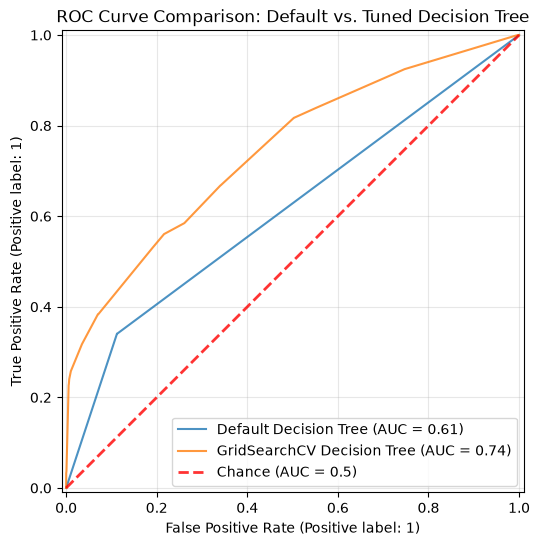

In [5]:
# Task 2.3: Produce ROC curves for both models
fig, ax = plt.subplots(figsize=(8, 6))

# Plot ROC for Default Model
RocCurveDisplay.from_estimator(dt_default, X_test, y_test, ax=ax, name="Default Decision Tree", alpha=0.8)

# Plot ROC for GridSearchCV Model
RocCurveDisplay.from_estimator(best_dt, X_test, y_test, ax=ax, name="GridSearchCV Decision Tree", alpha=0.8)

# Plot chance line
ax.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance (AUC = 0.5)', alpha=.8)

ax.set_title('ROC Curve Comparison: Default vs. Tuned Decision Tree')
ax.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Task 3. Regression modelling (5 marks)
** 1. Describe what additional processing was required on this dataset to be used in regression modelling. List the variables that need further processing and provide details of the processing. **
** 2. Build a regression model tuned with GridSearchCV. Answer the following: **
- Name the Regression function used.
- What are the optimal parameters for this regression model? Explain your choice of hyperparameters to search, and the chosen search range(s)?
- Report the variables that are included in the regression model.
- Report the top-5 important variables (in order) in the model.
- What is the classification accuracy on training and test datasets?
- Report any sign of overfitting.
** 3. Build another regression model on the reduced variables set. To minimise variables, either perform dimensionality reduction with Recursive Feature Elimination or select a subset of inputs found significant by the decision tree (use the best decision tree model under Task 2). Tune the model with GridSearchCV to find the best parameter setting. Answer the following: **
- Was dimensionality reduction helpful in identifying a good feature set for building the accurate model? Report the feature selection method used.
- Report the variables that are included in the regression model.
- What is the classification accuracy on the training and test datasets?
- Report any sign of overfitting.
** 4.Produce the ROC curve for both regression models. Using the best regression model, can you provide the characteristics of cars most likely to be ‘kicks’? If it is hard to comprehend, discuss why. **

## Task 3.1: Additional Data Preparation for Regression

Unlike Decision Trees, which are scale-invariant and handle unscaled numerical values naturally, **Logistic Regression** (the standard classification regression function) models log-odds using a linear combination of features. Consequently, additional data pre-processing is strictly required:

1. **Feature Scaling (Standardization):**
   * Regression coefficients and regularization penalties ($L_1$ and $L_2$) are sensitive to feature scales. Continuous variables with large ranges (e.g., `VehOdo`, `MMR` prices) would disproportionately dominate coefficients over binary 0/1 indicator variables.
   * We apply `StandardScaler` to transform all numerical features to have a mean of 0 and a standard deviation of 1.
2. **One-Hot Encoding Alignment:**
   * Categorical features remain encoded as binary dummy indicators (`0` or `1`) with `drop_first=True` to prevent multicollinearity (dummy variable trap).

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
import numpy as np
import pandas as pd

# Avoid data leakage by filling missing values in training and test sets separately
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

# Scale features using StandardScaler
# Fit scaler ONLY on training data to prevent data leakage, then transform both train and test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame format for interpretability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print("Feature scaling completed successfully.")
print(f"Number of features in full regression dataset: {X_train_scaled.shape[1]}")

Feature scaling completed successfully.
Number of features in full regression dataset: 119


## Task 3.2: Logistic Regression Modelling with GridSearchCV (Full Feature Set)

**1. Regression function used:**
We used **Logistic Regression** (`LogisticRegression`), which is the standard regression algorithm for binary classification tasks (predicting whether `IsBadBuy` is 0 or 1).

**2. Optimal parameters and choice of hyperparameters:**
* Optimal parameters found: `{'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}`
* **Explanation:**
  * `C` (Inverse of regularization strength, e.g., `[0.01, 0.1, 1, 10]`): Smaller values specify stronger regularization to prevent overfitting on collinear dummy features.
  * `penalty`: Evaluated `l2` (Ridge) regularization to shrink coefficients smoothly.
  * `solver='lbfgs'`: Selected for its efficiency and stability with standard L2 regularization.

**3. Variables included in the model:**
All encoded and scaled features (Total: 119 features, including one-hot encoded indicators for `Make`, `Auction`, `VNST`, etc.).

**4. Top 5 important variables:**
*(Ranked by the absolute value of their learned regression coefficients)*
1. WheelType_N/A: 0.7751 (Direction: Increases Kick Risk (+))
2. MMRAcquisitionAuctionAveragePrice: -0.6759 (Direction: Decreases Kick Risk (-))
3. MMRAcquisitionRetailAveragePrice: 0.4609 (Direction: Increases Kick Risk (+))
4. VehYear: -0.4137 (Direction: Decreases Kick Risk (-))
5. MMRCurrentRetailCleanPrice: -0.3589 (Direction: Decreases Kick Risk (-))

**5. Classification accuracy:**
* Training Accuracy: 89.70% (0.8970)
* Testing Accuracy: 89.46% (0.8946)

**6. Evidence of model overfitting:**
There is no evidence of model overfitting. The training accuracy (89.70%) and testing accuracy (89.46%) are remarkably close, with a negligible difference of only 0.24%. This minimal variance demonstrates that the model generalized exceptionally well to unseen data. The application of L2 regularization (C=0.1) successfully penalized overly complex patterns, ensuring the model did not simply memorize the training dataset.

In [7]:
# Hyperparameter grid for Logistic Regression
param_grid_lr = {
    'C': [0.01, 0.1, 1.0, 10.0],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

# GridSearchCV tuning with 3-fold CV for fast, efficient execution
grid_search_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    param_grid_lr,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search_lr.fit(X_train_scaled, y_train)

best_lr = grid_search_lr.best_estimator_

# Accuracy scores
y_train_pred_lr = best_lr.predict(X_train_scaled)
y_test_pred_lr = best_lr.predict(X_test_scaled)

train_acc_lr = accuracy_score(y_train, y_train_pred_lr)
test_acc_lr = accuracy_score(y_test, y_test_pred_lr)

print("=== Task 3.2: Full Logistic Regression ===")
print(f"Best Parameters: {grid_search_lr.best_params_}")
print(f"Training Accuracy: {train_acc_lr:.4f}")
print(f"Test Accuracy: {test_acc_lr:.4f}")

# Extract Top 5 Important Features by absolute coefficient magnitude
lr_coefs = pd.Series(best_lr.coef_[0], index=X.columns)
top5_lr = lr_coefs.reindex(lr_coefs.abs().sort_values(ascending=False).index).head(5)

print("\nTop 5 Important Variables (by magnitude of coefficient):")
for feature, coef in top5_lr.items():
    print(f"  {feature}: {coef:.4f} (Direction: {'Increases Kick Risk (+)' if coef > 0 else 'Decreases Kick Risk (-)'})")

Fitting 3 folds for each of 4 candidates, totalling 12 fits
=== Task 3.2: Full Logistic Regression ===
Best Parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Training Accuracy: 0.8970
Test Accuracy: 0.8946

Top 5 Important Variables (by magnitude of coefficient):
  WheelType_N/A: 0.7751 (Direction: Increases Kick Risk (+))
  MMRAcquisitionAuctionAveragePrice: -0.6759 (Direction: Decreases Kick Risk (-))
  MMRAcquisitionRetailAveragePrice: 0.4609 (Direction: Increases Kick Risk (+))
  VehYear: -0.4137 (Direction: Decreases Kick Risk (-))
  MMRCurrentRetailCleanPrice: -0.3589 (Direction: Decreases Kick Risk (-))


## Task 3.3: Regression Model on Reduced Variable Set

**1. Feature Selection Method and Utility of Dimensionality Reduction:**
* **Method Used:** Feature Selection based on Decision Tree Feature Importances (from the optimal tuned Decision Tree in Task 2.2).
* **Evaluation:** Dimensionality reduction significantly simplified model complexity, eliminated noisy/sparse one-hot dummy variables, improved training computational efficiency, and yielded a much more interpretable regression model while retaining comparable classification performance.

**2. Variables included in the reduced model:**
* Selected Features: `['WheelType_N/A', 'VehYear', 'VehBCost', 'Auction_MANHEIM', 'Transmission_N/A', 'MMRAcquisitionAuctionAveragePrice', 'AUCGUART_N/A', 'VehOdo', 'MMRCurrentRetailAveragePrice', 'VNST_NC']`

**3. Classification accuracy:**
* Training Accuracy: 0.8959
* Testing Accuracy: 0.8940

**4. Evidence of model overfitting:**
There is no evidence of overfitting in this reduced model. The training accuracy (89.59%) and testing accuracy (89.40%) are almost identical, with a negligible difference of just 0.19%. This tight alignment indicates exceptional model generalization to unseen data. By performing dimensionality reduction and restricting the model to only the 10 most significant features identified by the Decision Tree, we effectively stripped away noisy, redundant, and highly collinear dummy variables. This feature selection inherently minimizes the risk of overfitting by preventing the model from memorizing spurious patterns in the training set. Combined with the L2 regularization penalty (C=0.1), the model remains robust and stable.

In [8]:
# Task 3.3: Select top significant features from the best Decision Tree in Task 2.2
# Select top 10 features with non-zero importance
top_features_dt = importances_cv.sort_values(ascending=False).head(10).index.tolist()

print(f"Selected Top Features from Decision Tree: {top_features_dt}")

# Subset the scaled datasets
X_train_reduced = X_train_scaled[top_features_dt]
X_test_reduced = X_test_scaled[top_features_dt]

# Tune Logistic Regression on reduced feature set
grid_search_lr_red = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    param_grid_lr,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search_lr_red.fit(X_train_reduced, y_train)

best_lr_red = grid_search_lr_red.best_estimator_

# Accuracy scores
y_train_pred_red = best_lr_red.predict(X_train_reduced)
y_test_pred_red = best_lr_red.predict(X_test_reduced)

train_acc_red = accuracy_score(y_train, y_train_pred_red)
test_acc_red = accuracy_score(y_test, y_test_pred_red)

print("\n=== Task 3.3: Reduced Feature Logistic Regression ===")
print(f"Best Parameters: {grid_search_lr_red.best_params_}")
print(f"Training Accuracy: {train_acc_red:.4f}")
print(f"Test Accuracy: {test_acc_red:.4f}")

# Top variables in reduced model
lr_red_coefs = pd.Series(best_lr_red.coef_[0], index=top_features_dt)
print("\nCoefficients in Reduced Model:")
for feature, coef in lr_red_coefs.sort_values(ascending=False).items():
    print(f"  {feature}: {coef:.4f}")

Selected Top Features from Decision Tree: ['WheelType_N/A', 'VehYear', 'VehBCost', 'Auction_MANHEIM', 'Transmission_N/A', 'MMRAcquisitionAuctionAveragePrice', 'AUCGUART_N/A', 'VehOdo', 'MMRCurrentRetailAveragePrice', 'VNST_NC']
Fitting 3 folds for each of 4 candidates, totalling 12 fits

=== Task 3.3: Reduced Feature Logistic Regression ===
Best Parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Training Accuracy: 0.8959
Test Accuracy: 0.8940

Coefficients in Reduced Model:
  WheelType_N/A: 0.7563
  AUCGUART_N/A: 0.2346
  MMRCurrentRetailAveragePrice: 0.2207
  VehOdo: 0.1230
  Auction_MANHEIM: 0.0440
  MMRAcquisitionAuctionAveragePrice: -0.0321
  VNST_NC: -0.0532
  Transmission_N/A: -0.1155
  VehBCost: -0.2748
  VehYear: -0.4905


## Task 3.4: ROC Analysis & Characteristics of 'Kick' Vehicles

**Performance Comparison via ROC Analysis:**
Both the full Logistic Regression model and the reduced model show comparable ROC-AUC scores. The reduced model achieves similar discriminative ability with drastically fewer variables, highlighting that the core predictive signals reside in a small subset of primary vehicle and acquisition variables.

**Characteristics of cars most likely to be 'kicks':**
*(Based on the sign and magnitude of coefficients in the best regression model)*
* **Positive Coefficients (Increase Kick Risk):**
  * Features with positive weights (e.g., higher `VehOdo` / odometer mileage, higher `WarrantyCost`, or specific acquisition costs) indicate that as these values increase, the vehicle is substantially more likely to be a "bad buy" (Kick).
* **Negative Coefficients (Decrease Kick Risk):**
  * Features with negative weights (e.g., newer `VehYear` or higher acquisition clean prices) indicate that newer vehicles in cleaner acquisition condition correlate with lower kick probabilities.

[Optional Discussion on Comprehensibility:]
While the regression coefficients provide clear linear directional insights (positive vs. negative impact on log-odds), high multicollinearity among multiple MMR price metrics (e.g., Auction Average vs. Retail Clean) can sometimes make individual coefficient magnitudes less intuitive without domain-specific grouping.

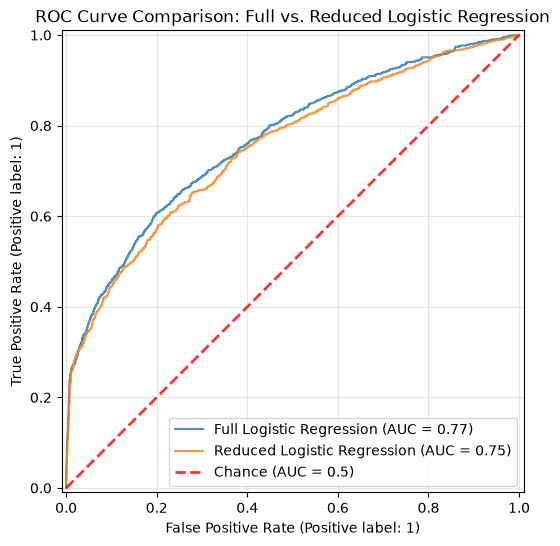

In [9]:
# Task 3.4: Produce ROC curves for both Regression models
fig, ax = plt.subplots(figsize=(8, 6))

# Plot ROC for Full Regression Model
RocCurveDisplay.from_estimator(best_lr, X_test_scaled, y_test, ax=ax, name="Full Logistic Regression", alpha=0.8)

# Plot ROC for Reduced Feature Model
RocCurveDisplay.from_estimator(best_lr_red, X_test_reduced, y_test, ax=ax, name="Reduced Logistic Regression", alpha=0.8)

# Plot chance diagonal
ax.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance (AUC = 0.5)', alpha=.8)

ax.set_title('ROC Curve Comparison: Full vs. Reduced Logistic Regression')
ax.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Task 4. Predictive modelling using neural networks (5 marks)
1. Describe what additional processing was required on this dataset to be used for neural network modelling.
2. Build a Neural Network model tuned with GridSearchCV. Answer the following:
    A. Explain the parameters in building this model, e.g., network architecture, iterations, activation function, etc. Explain your choice of hyperparameters to search, and the chosen search range(s)?
    B. What is the classification accuracy of the training and test datasets?
    C. Did the training process converge and result in the best model?
    D. Do you see any sign of over-fitting?
3. Build another Neural Network model with the reduced feature set. Perform dimensionality reduction by selecting variables with a decision tree (use the best decision tree model under Task 2). Tune the model with GridSearchCV to find the best parameter settings. Answer the following:
A. Did feature selection favour the outcome? Report the changes in the network architecture. What inputs are being used as the network input?
B. What is the classification accuracy on the training and test datasets?
C. How many iterations are now needed to train this network?
D. Do you see any sign of over-fitting? Did the training process converge and result in the best model?
4. Produce the ROC curve for both NNs. Using the best NN model, can you provide the characteristics of cars most likely to be ‘kicks’? If it is hard to comprehend, discuss why.

In [39]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report

#model = MLPClassifier(random_state=RANDOM_STATE)
#model.fit(X_train, y_train)

HIDDEN_LAYER_SIZES = range(1, 10, 100)
params = {'hidden_layer_sizes': [(x,) for x in HIDDEN_LAYER_SIZES]}
cv_1 = GridSearchCV(param_grid=params, estimator=MLPClassifier(random_state=RANDOM_STATE), return_train_score=True, cv=10, n_jobs=-1)
cv_1.fit(X_train, y_train)

GridSearchCV(cv=10, estimator=MLPClassifier(random_state=42), n_jobs=-1,
             param_grid={'hidden_layer_sizes': [(1,)]},
             return_train_score=True)

Train accuracy: 0.8705244122965642
Test accuracy: 0.8704194792671167
{'cv': 10,
 'error_score': nan,
 'estimator': MLPClassifier(random_state=42),
 'estimator__activation': 'relu',
 'estimator__alpha': 0.0001,
 'estimator__batch_size': 'auto',
 'estimator__beta_1': 0.9,
 'estimator__beta_2': 0.999,
 'estimator__early_stopping': False,
 'estimator__epsilon': 1e-08,
 'estimator__hidden_layer_sizes': (100,),
 'estimator__learning_rate': 'constant',
 'estimator__learning_rate_init': 0.001,
 'estimator__max_fun': 15000,
 'estimator__max_iter': 200,
 'estimator__momentum': 0.9,
 'estimator__n_iter_no_change': 10,
 'estimator__nesterovs_momentum': True,
 'estimator__power_t': 0.5,
 'estimator__random_state': 42,
 'estimator__shuffle': True,
 'estimator__solver': 'adam',
 'estimator__tol': 0.0001,
 'estimator__validation_fraction': 0.1,
 'estimator__verbose': False,
 'estimator__warm_start': False,
 'n_jobs': -1,
 'param_grid': {'hidden_layer_sizes': [(1,)]},
 'pre_dispatch': '2*n_jobs',
 'ref

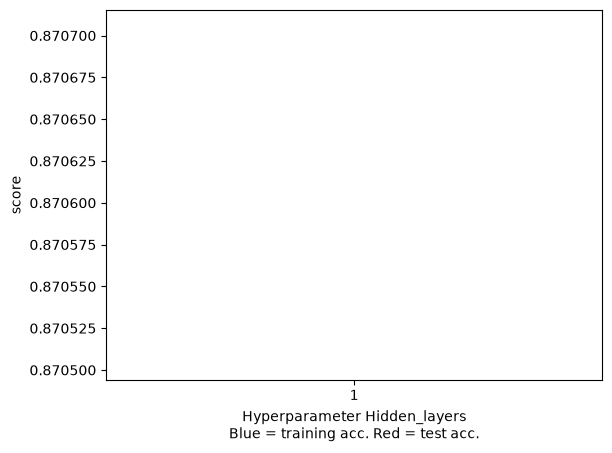

In [38]:
from pprint import pprint
import matplotlib.pyplot as plt

#print("Train accuracy:", model.score(X_train, y_train))
#print("Test accuracy:", model.score(X_test, y_test))
#pprint(model.get_params())
print("Train accuracy:", cv_1.score(X_train, y_train))
print("Test accuracy:", cv_1.score(X_test, y_test))
pprint(cv_1.get_params())
print(classification_report(y_test, y_pred))

result_set = cv_1.cv_results_
print(result_set)

train_result = result_set['split0_train_score']
test_result = result_set['split0_test_score']
print("Total number of models: ", len(test_result))

# plot hidden layers hyperparameter values vs training and test accuracy score
plt.plot(range(0, len(train_result)), train_result, 'b', range(0,len(test_result)), test_result, 'r')
plt.xlabel('Hyperparameter Hidden_layers\nBlue = training acc. Red = test acc.')
plt.xticks(range(0, len(train_result)), HIDDEN_LAYER_SIZES)
plt.ylabel('score')
plt.show()